**Master en Bioinformática y Biología Computacional, UAM**
## **Minería de texto**
# **Práctica de laboratorio 3: Redes neuronales para análisis de sentimientos**


---



# ***Ejercicio 1 - FFNs***

# Carga y preprocesado de datos - One-hot encoding

In [ ]:
# Montamos el drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Fijamos semillas para generación de números aleatorios
import numpy as np
import tensorflow as tf

np.random.seed(1)
tf.random.set_seed(2)

In [ ]:
import re
import pandas as pd

# Utilizamos el Stanford Sentiment Treebank (SST) como corpus de prueba para análisis de sentimientos de textos
# Cargamos y procesamos los datos para tratarlos como un problema de clasificación binaria de sentimientos
# Convertimos la escala de sentimientos de [1,5] a {0,1}
def load_sst_dataset(file_path, label_map={0:0, 1:0, 2:None, 3:1, 4:1}):
    data = []
    with open(file_path) as f:
        for i, line in enumerate(f):
            instance = {}
            instance['label'] = label_map[int(line[1])]
            if instance['label'] is None:
                continue

            # Filtramos caracteres y etiquetas de parseo
            text = re.sub(r'\s*(\(\d)|(\))\s*', '', line)
            instance['text'] = text[1:]
            data.append(instance)
    data = pd.DataFrame(data)
    return data

data_folder = 'drive/My Drive/Colab Notebooks/mintex2526-lab3/data/'
training_set = load_sst_dataset(data_folder + 'sst_training.txt') # conjunto de datos de entrenamiento
validation_set = load_sst_dataset(data_folder + 'sst_validation.txt') # conjunto de datos de validación
test_set = load_sst_dataset(data_folder + 'sst_test.txt') # conjunto de datos de test

print('Instancias de entrenamiento: {}'.format(len(training_set)))
print('Instancias de de validación: {}'.format(len(validation_set)))
print('Instancias de de test: {}'.format(len(test_set)))

Instancias de entrenamiento: 6920
Instancias de de validación: 872
Instancias de de test: 1821


In [ ]:
from tensorflow.keras.preprocessing import text
from sklearn.utils import shuffle

# Desordenamos los conjuntos de datos
training_set = shuffle(training_set)
validation_set = shuffle(validation_set)
test_set = shuffle(test_set)

# Separamos textos y etiquetas de los conjuntos de datos
training_texts = training_set.text
training_labels = training_set.label
validation_texts = validation_set.text
validation_labels = validation_set.label
test_texts = test_set.text
test_labels = test_set.label

# Construimos un índice (vocabulario) para las 1000 palabras más frecuentes en el conjunto de datos de entrenamiento
tokenizer = text.Tokenizer(num_words=1000)
tokenizer.fit_on_texts(training_texts)

print("10 palabras del vocabulario con mayor frecuencia:")
words_index = tokenizer.word_index
for word, index in list(words_index.items())[:10]:
    count = tokenizer.word_counts[word]
    print(f"\t{word}  (índice: {index}, frecuencia: {count})")
print()

print("10 palabras del vocabulario con menor frecuencia:")
sorted_word_counts = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=False)
last_words_counts = sorted_word_counts[:10]
for word, count in last_words_counts:
    index = tokenizer.word_index[word]
    print(f"\t{word}  (índice: {index}, frecuencia: {count})")

10 palabras del vocabulario con mayor frecuencia:
	the  (índice: 1, frecuencia: 5996)
	a  (índice: 2, frecuencia: 4385)
	and  (índice: 3, frecuencia: 3869)
	of  (índice: 4, frecuencia: 3680)
	to  (índice: 5, frecuencia: 2464)
	is  (índice: 6, frecuencia: 2099)
	's  (índice: 7, frecuencia: 2025)
	it  (índice: 8, frecuencia: 1952)
	that  (índice: 9, frecuencia: 1613)
	in  (índice: 10, frecuencia: 1581)

10 palabras del vocabulario con menor frecuencia:
	aid  (índice: 7198, frecuencia: 1)
	milking  (índice: 7199, frecuencia: 1)
	ken  (índice: 7200, frecuencia: 1)
	vacuous  (índice: 7201, frecuencia: 1)
	embody  (índice: 7202, frecuencia: 1)
	nouvelle  (índice: 7203, frecuencia: 1)
	enact  (índice: 7204, frecuencia: 1)
	chapter  (índice: 7205, frecuencia: 1)
	playwright  (índice: 7206, frecuencia: 1)
	drinker  (índice: 7207, frecuencia: 1)


In [ ]:
# Vectorizamos los textos mediante la representación one-hot encoding
x_training = tokenizer.texts_to_matrix(training_texts, mode='binary')
y_training = training_labels
x_validation = tokenizer.texts_to_matrix(validation_texts, mode='binary')
y_validation = validation_labels
x_test = tokenizer.texts_to_matrix(test_texts, mode='binary')
y_test = test_labels

print('Dimensiones del conjunto de entrenamiento: {}'.format(x_training.shape))
print('Dimensiones del conjunto de validación: {}'.format(x_validation.shape))
print('Dimensiones del conjunto de test: {}'.format(x_test.shape))

Dimensiones del conjunto de entrenamiento: (6920, 1000)
Dimensiones del conjunto de validación: (872, 1000)
Dimensiones del conjunto de test: (1821, 1000)


In [ ]:
# Comprobación de algunos vectores generados:
# Iteramos sobre n textos (de entrenamiento) y sus vectores correspondientes
n = 3

index_to_word = tokenizer.index_word # Mapeos de índices a palabras en el vocabulario
word_counts = tokenizer.word_counts # Frecuencias de las palabras en los textos

for i, (text, text_vector) in enumerate(zip(training_texts[:n], x_training[:n]), start=1):
    print(f"Texto {i}: {text}")
    print(f"Vector: {text_vector}")
    print("Palabras:")
    for index, value in enumerate(text_vector):
        # Si el valor en el vector es 1, obtenemos la palabra correspondiente, junto con su índice y frecuencia en el vocabulario
        if value == 1:
            word = index_to_word.get(index)
            word_frequency = word_counts.get(word, 0) if word else 0
            print(f"\t{word} (índice={index}, frecuencia={word_frequency})")
    print()

Texto 1: It is dark , brooding and slow , and takes its central idea way too seriously .
Vector: [0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.

# Construcción de la red

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

input_size = x_training[0].shape[0] # la longitud del vector de entrada es igual al tamaño del vocabulario

# Definimos una red neuronal feedforward con una única capa oculta de 16 unidades
# y ReLU como función de activación
model = Sequential()
model.add(Dense(units=16, activation='relu', input_shape=(input_size,))) # Nota: no es necesario indicar input_shape en capas sucesivas
model.add(Dense(units=1, activation='sigmoid'))

# Compilamos la red usando la entropía cruzada binaria como función de pérdida,
# el algoritmo Adam como optimizador del descenso por gradiente,
# y accuracy como métrica de evaluación en entrenamiento y validación
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Opcionalmente se pueden utilizar otras funciones de activación (e.g., tanh, sigmoid) en vez de ReLU
# y otras funciones de pérdida como mean squared error (MSE)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        16,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,033 (62.63 KB)

 Trainable params: 16,033 (62.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamos la red durante 100 épocas y con batches de tamaño 32
history = model.fit(x_training, y_training, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=1)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5833 - loss: 0.6746 - val_accuracy: 0.7225 - val_loss: 0.5826
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7508 - loss: 0.5551 - val_accuracy: 0.7626 - val_loss: 0.5063
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7894 - loss: 0.4730 - val_accuracy: 0.7638 - val_loss: 0.4906
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8097 - loss: 0.4350 - val_accuracy: 0.7661 - val_loss: 0.4919
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8140 - loss: 0.4129 - val_accuracy: 0.7615 - val_loss: 0.4984
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8214 - loss: 0.3973 - val_accuracy: 0.7615 - val_loss: 0.5068
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8257 - loss: 0.3850 - val_accuracy: 0.7603 - val_loss: 0.5154
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8297 - loss: 0.3744 - val_accu

**Ejercicio 1a - Red de una capa oculta**

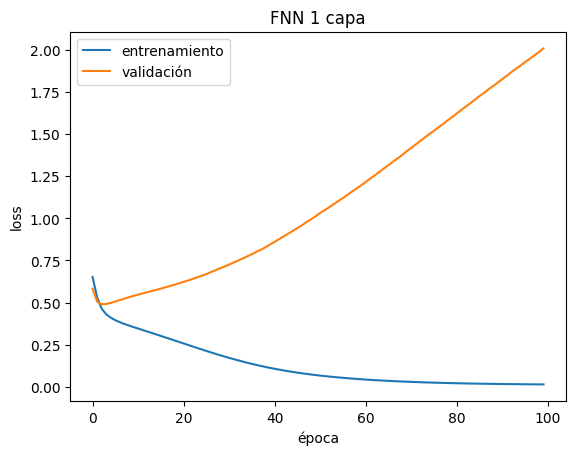

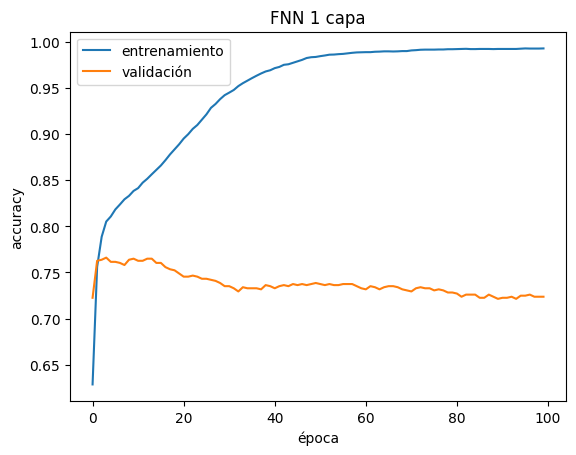

In [ ]:
import matplotlib.pyplot as plt

# Visualizamos un gráfica con el LOSS alcanzado en cada época para los conjuntos de entrenamiento y de validación
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('FNN 1 capa')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Visualizamos un gráfica con el ACCURACY alcanzado en cada época para los conjuntos de entrenamiento y de validación
# TO DO
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('FNN 1 capa')
plt.ylabel('accuracy')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

**Ejercicio 1b - Red multicapa**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │        16,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,305 (63.69 KB)

 Trainable params: 16,305 (63.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5503 - loss: 0.6835 - val_accuracy: 0.7385 - val_loss: 0.5674
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7475 - loss: 0.5340 - val_accuracy: 0.7683 - val_loss: 0.4941
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8002 - loss: 0.4422 - val_accuracy: 0.7638 - val_loss: 0.5013
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8202 - loss: 0.4040 - val_accuracy: 0.7603 - val_loss: 0.5148
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8353 - loss: 0.3701 - val_accuracy: 0.7615 - val_loss: 0.5362
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8602 - loss: 0.3322 - val_accuracy: 0.7557 - val_loss: 0.5652
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8816 - loss: 0.2911 - val_accuracy: 0.7534 - val_loss: 0.6063
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9054 - loss: 0.2518 - val_accu

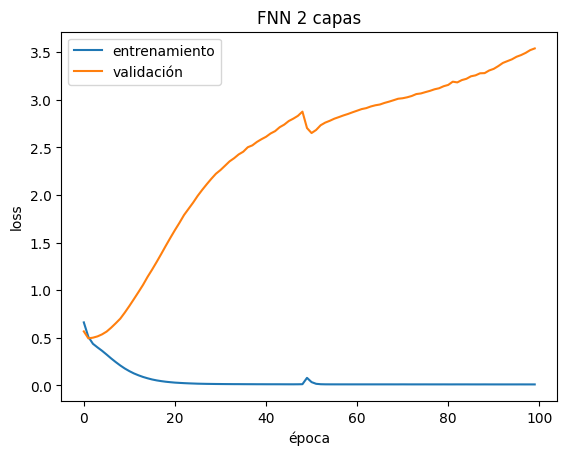

In [ ]:
# Añadimos una capa oculta adicional al modelo
model = Sequential()
# TO DO
model.add(Dense(units=16, activation='relu', input_shape=(input_size,)))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

history_2 = model.fit(x_training, y_training, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=1)

# Visualizamos una gráfica con la evolución de LOSS alcanzado en cada época para los conjuntos de entrenamiento y de validación
# TO DO
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('FNN 2 capas')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

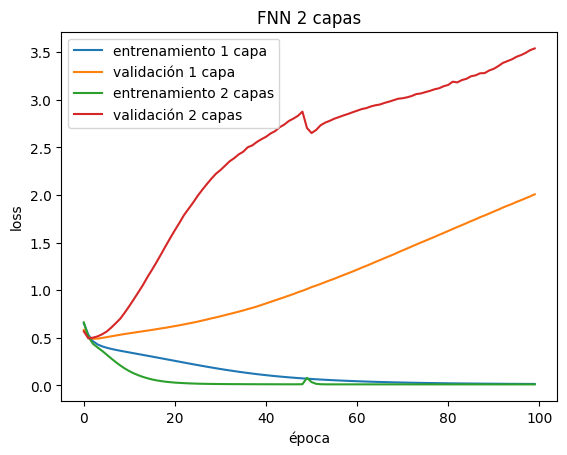

In [ ]:
# Visualizamos una gráfica comparativa de la evolución de LOSS por épocas usando una o dos capas ocultas
plt.title('FNN 1 capa vs. 2 capas')
# TO DO
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('FNN 2 capas')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento 1 capa', 'validación 1 capa','entrenamiento 2 capas',
            'validación 2 capas'], loc='upper left')
plt.show()


**Ejercicio 1c - Evaluación de hiperparámetros mediante grid search**

In [ ]:
# Comentario: para generar un modelo configurado con una serie de parámetros dada se aconseja implementar una función get_model,
# que recibe tales parámetros como argumentos de entrada, y retorna el modelo correspondiente como salida
def get_model(lrs, regs, drs):
    model = Sequential()
    model.add(Dense(units=16, activation='relu', input_shape=(input_size,)))
    model.add(Dropout(drs))
    model.add(Dense(units=16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=lrs)

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    return model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time
lrs = [0.0001, 0.001, 0.01] # valores de la learning rate
regs = [0.0, 0.0001] # valores de regularización L2
drs = [0.0, 0.2, 0.5] # valores de dropout

num_epochs = 100
early_stop = EarlyStopping(monitor='val_loss', patience=1) # para parar el entrenamiento antes de num_epochs atendiendo al error en validación

# Imprimimos por pantalla los valores valores de LOSS y ACCURACY de entrenamiento y validación de cada modelo, época a epóca
histories = {}
for lr in lrs:
    for reg in regs:
        for dr in drs:
            # TO DO
            print(f"lr={lr}, reg={reg}, dr={dr}")
            model = get_model(lr, reg, dr)
            history = model.fit(x_training, y_training, epochs=100,batch_size=32,
                                validation_data=(x_validation, y_validation), verbose=1)
            histories[(lr, reg, dr)] = history

lr=0.0001, reg=0.0, dr=0.0
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4832 - loss: 0.6955 - val_accuracy: 0.5252 - val_loss: 0.6892
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5653 - loss: 0.6868 - val_accuracy: 0.5952 - val_loss: 0.6829
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6172 - loss: 0.6791 - val_accuracy: 0.6388 - val_loss: 0.6742
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6600 - loss: 0.6681 - val_accuracy: 0.6686 - val_loss: 0.6605
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6929 - loss: 0.6518 - val_accuracy: 0.7099 - val_loss: 0.6404
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7146 - loss: 0.6295 - val_accuracy: 0.7271 - val_loss: 0.6157
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7335 - loss: 0.6026 - val_accuracy: 0.7477 - val_loss: 0.5896
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7478 - loss: 0.5739 - val_accuracy: 0.758

In [ ]:
# Obtenemos y visualizamos los parámetros de la mejor época atendiendo a los valores de ACCURACY en validación
# TO DO
best_params = None
best_accuracy = 0.0
for params, history in histories.items():
    val_accuracy = history.history['val_accuracy'][-1]
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_params = params
        best_history = history

print("Mejores parámetros: lr={}, reg={}, dr={}".format(*best_params))
print("Mejor accuracy en validación: {}".format(best_accuracy))


Mejores parámetros: lr=0.0001, reg=0.0001, dr=0.2
Mejor accuracy en validación: 0.7545871734619141


# ***Ejercicio 2 - LSTMs***

# Preprocesado de datos - Tokenization y sequence padding

In [ ]:
from tensorflow.keras import preprocessing

# Creamos un tokenier que considera las 10000 palabras más frecuentes en el corpus
max_words = 10000
tokenizer = preprocessing.text.Tokenizer(num_words=max_words)

# Construimos el índice (diccionario) de palabras a partir del conjunto de datos de entrenamiento
tokenizer.fit_on_texts(training_texts)
word_index = tokenizer.word_index

# Obtenemos los textos como secuencias de enteros
trainining_sequences = tokenizer.texts_to_sequences(training_texts)
validation_sequences = tokenizer.texts_to_sequences(validation_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Padding: convertimos las secuencias de enteros a un tensor 2D de forma (numero_secuencias, longitud_secuencia)
# Con ello igualamos la longitud de las secuencias de entrada
max_seq = 40
x_training = preprocessing.sequence.pad_sequences(trainining_sequences, maxlen=max_seq)
x_validation = preprocessing.sequence.pad_sequences(validation_sequences, maxlen=max_seq)
x_test = preprocessing.sequence.pad_sequences(test_sequences, maxlen=max_seq)

y_traininig = training_labels
y_validation = validation_labels
y_test = test_labels

print('Dimensiones del conjunto de entrenamiento: {}'.format(x_training.shape))
print('Dimensiones del conjunto de validación: {}'.format(x_validation.shape))
print('Dimensiones del conjunto de test: {}'.format(x_test.shape))

# Visualizamos un par de instancias de entrenamiento
print('\nTexto: {}\nVector padded: {}'.format(training_texts.iloc[0], x_training[0]))
print('\nTexto: {}\nVector padded: {}'.format(training_texts.iloc[1], x_training[1]))

Dimensiones del conjunto de entrenamiento: (6920, 40)
Dimensiones del conjunto de validación: (872, 40)
Dimensiones del conjunto de test: (1821, 40)

Texto: It is dark , brooding and slow , and takes its central idea way too seriously .
Vector padded: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    8    6
  276 2487    3  470    3  234   19 1109  308   72   48  875]

Texto: To honestly address the flaws inherent in how medical aid is made available to American workers , a more balanced or fair portrayal of both sides will be needed .
Vector padded: [   0    0    0    0    0    0    0    0    0    0    0    0    5 1462
 4935    1  648 2121   10  107 2983 7198    6   97 4936    5  196 4937
    2   30 2488   41 1463 1615    4  124 1316   60   21  936]


# Construcción de la red

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM

embedding_size = 128
lstm_hidden_size = 128

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamos la red durante 20 épocas y con batches de tamaño 128
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.5924 - loss: 0.6628 - val_accuracy: 0.7867 - val_loss: 0.4834
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.8556 - loss: 0.3606 - val_accuracy: 0.7844 - val_loss: 0.4913
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - accuracy: 0.9265 - loss: 0.1978 - val_accuracy: 0.7833 - val_loss: 0.5653
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.9659 - loss: 0.1034 - val_accuracy: 0.7798 - val_loss: 0.6678
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.9722 - loss: 0.0843 - val_accuracy: 0.7523 - val_loss: 0.8752
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.9663 - loss: 0.0944 - val_accuracy: 0.7741 - val_loss: 0.6867
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step - accuracy: 0.9871 - loss: 0.0482 - val_accuracy: 0.7913 - val_loss: 0.9079
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - accuracy: 0.9937 - loss: 0.0282 - val_accu

**Ejercicio 2a - LSTM de una capa**

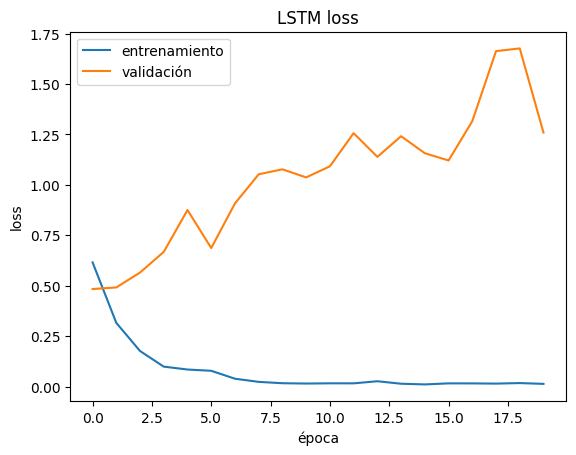

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7683 - loss: 1.2913
Accuracy:  0.7753981351852417


In [ ]:
import matplotlib.pyplot as plt

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

**Ejercicio 2b - Tamaño de embeddings y número de unidades LSTM**



Prueba diferentes tamaños de embeddings y número de unidades LSTM.
¿Observas alguna diferencia en las curvas de pérdida y precisión?
¿Qué sucede con un tamaño de embeddings muy pequeño (por ejemplo, 8) o unidades LSTM (por ejemplo, 16)? ¿Y qué ocurre cuando hacemos lo contrario?



Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.5316 - loss: 0.6895 - val_accuracy: 0.6342 - val_loss: 0.6692
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/step - accuracy: 0.7037 - loss: 0.6111 - val_accuracy: 0.7810 - val_loss: 0.4959
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.8497 - loss: 0.3868 - val_accuracy: 0.8108 - val_loss: 0.4451
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.9132 - loss: 0.2511 - val_accuracy: 0.7947 - val_loss: 0.5498
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.9411 - loss: 0.1707 - val_accuracy: 0.7901 - val_loss: 0.5707
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9609 - loss: 0.1270 - val_accuracy: 0.7638 - val_loss: 0.5527
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.9556 - loss: 0.1263 - val_accuracy: 0.7741 - val_loss: 0.6888
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.9721 - loss: 0.0784 - val_accuracy: 

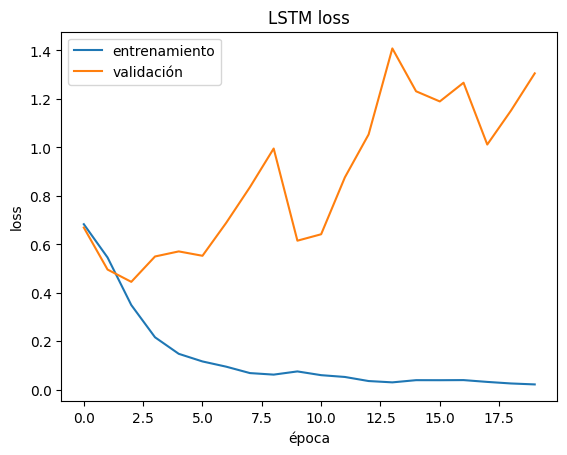

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7583 - loss: 1.4467
Accuracy:  0.7627677321434021


In [ ]:
# TO DO
embedding_size = 8
lstm_hidden_size = 128

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5766 - loss: 0.6815 - val_accuracy: 0.7741 - val_loss: 0.5481
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8277 - loss: 0.4542 - val_accuracy: 0.8062 - val_loss: 0.4412
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9173 - loss: 0.2528 - val_accuracy: 0.8062 - val_loss: 0.4702
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9542 - loss: 0.1556 - val_accuracy: 0.7970 - val_loss: 0.5248
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9740 - loss: 0.1023 - val_accuracy: 0.7913 - val_loss: 0.5762
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9822 - loss: 0.0721 - val_accuracy: 0.7856 - val_loss: 0.6128
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9811 - loss: 0.0676 - val_accuracy: 0.7810 - val_loss: 0.7224
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9765 - loss: 0.0767 - val_accuracy: 0.7661 - v

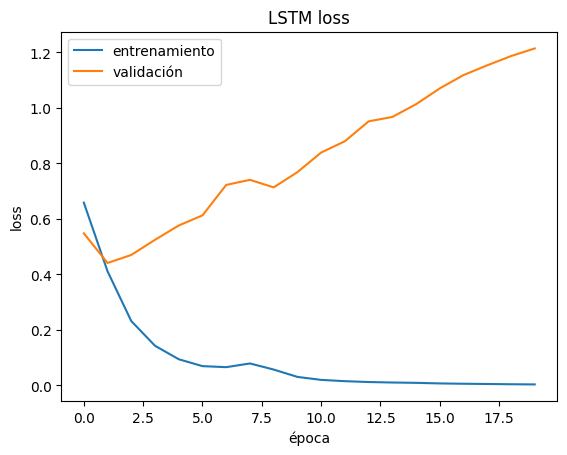

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7854 - loss: 1.1564
Accuracy:  0.7830862402915955


In [ ]:
embedding_size = 128
lstm_hidden_size = 16

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 563ms/step - accuracy: 0.6051 - loss: 0.6520 - val_accuracy: 0.7798 - val_loss: 0.4863
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 552ms/step - accuracy: 0.8644 - loss: 0.3412 - val_accuracy: 0.7741 - val_loss: 0.4693
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 576ms/step - accuracy: 0.9320 - loss: 0.1763 - val_accuracy: 0.7764 - val_loss: 0.5789
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 733ms/step - accuracy: 0.9674 - loss: 0.0962 - val_accuracy: 0.7706 - val_loss: 0.6158
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 629ms/step - accuracy: 0.9725 - loss: 0.0854 - val_accuracy: 0.7580 - val_loss: 0.6940
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 621ms/step - accuracy: 0.9537 - loss: 0.1373 - val_accuracy: 0.7695 - val_loss: 0.7276
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 559ms/step - accuracy: 0.9905 - loss: 0.0401 - val_accuracy: 0.7901 - val_loss: 0.8558
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 43s 595ms/step - accuracy: 0.9934 - loss: 0.0257 - val_accu

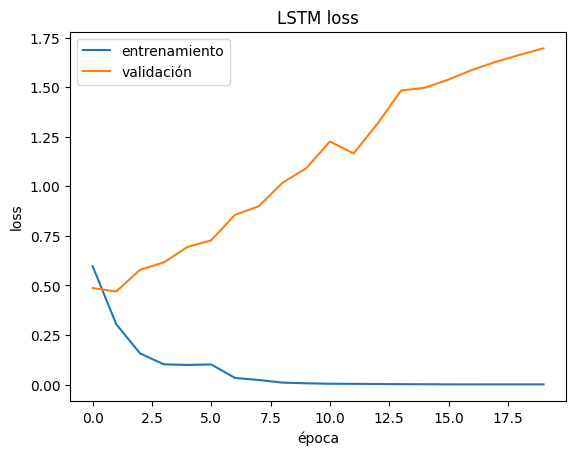

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7753 - loss: 1.8065
Accuracy:  0.7819879055023193


In [ ]:
embedding_size = 256
lstm_hidden_size = 256

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

# ***Ejercicio 3 - LSTMs avanzadas***

**Ejercicio 3a - Stacked LSTMs**

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 400ms/step - accuracy: 0.5110 - loss: 0.6928 - val_accuracy: 0.5700 - val_loss: 0.6864
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 357ms/step - accuracy: 0.6076 - loss: 0.6663 - val_accuracy: 0.7225 - val_loss: 0.5633
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 383ms/step - accuracy: 0.7569 - loss: 0.5115 - val_accuracy: 0.7810 - val_loss: 0.5030
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - accuracy: 0.8504 - loss: 0.3634 - val_accuracy: 0.7787 - val_loss: 0.5260
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 439ms/step - accuracy: 0.9057 - loss: 0.2604 - val_accuracy: 0.7810 - val_loss: 0.5784
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 353ms/step - accuracy: 0.9373 - loss: 0.1874 - val_accuracy: 0.7706 - val_loss: 0.6143
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 22s 393ms/step - accuracy: 0.9494 - loss: 0.1441 - val_accuracy: 0.7592 - val_loss: 0.7182
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 355ms/step - accuracy: 0.9667 - loss: 0.0977 - val_accu

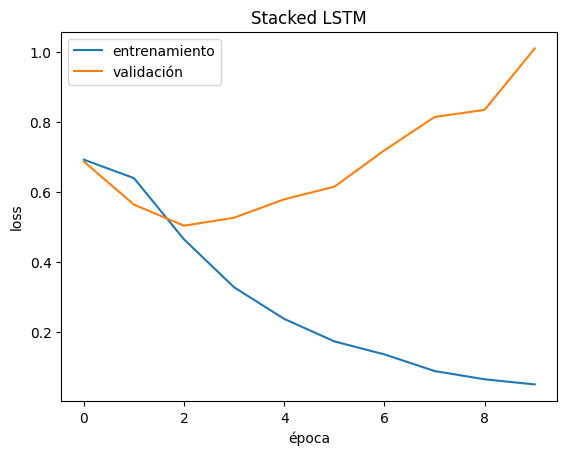

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7778 - loss: 1.0083
Accuracy:  0.7732015252113342


In [ ]:
# Creamos un stack con capa de entrada de embeddings, dos capas intermedias (ocultas) de LSTMs, y una capa de salida con función de activación sigmoidal
model = Sequential()
embedding_size = 128
lstm_hidden_size = 128
# TO DO
model.add(Embedding(max_words, embedding_size, mask_zero=True))
model.add(LSTM(lstm_hidden_size, return_sequences=True))
model.add(LSTM(lstm_hidden_size))
model.add(Dense(1, activation='sigmoid'))

# Usamos el optimizador RMSProp (Root Mean Square Propagation) appropiado para RNNs
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
model.summary()

# Entrenamos el modelo
history_lstm_stacked = model.fit(x_training, y_training, epochs=10, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

plt.plot(history_lstm_stacked.history['loss'])
plt.plot(history_lstm_stacked.history['val_loss'])
plt.title('Stacked LSTM')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

**Ejercicio 3b - Bidirectional LSTMs**

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/55 - 22s - 402ms/step - accuracy: 0.6373 - loss: 0.6332 - val_accuracy: 0.7706 - val_loss: 0.5281
Epoch 2/10
55/55 - 16s - 283ms/step - accuracy: 0.8590 - loss: 0.3540 - val_accuracy: 0.7856 - val_loss: 0.4907
Epoch 3/10
55/55 - 16s - 285ms/step - accuracy: 0.9212 - loss: 0.2092 - val_accuracy: 0.7626 - val_loss: 0.5742
Epoch 4/10
55/55 - 15s - 281ms/step - accuracy: 0.9558 - loss: 0.1271 - val_accuracy: 0.7649 - val_loss: 0.7920
Epoch 5/10
55/55 - 21s - 389ms/step - accuracy: 0.9743 - loss: 0.0816 - val_accuracy: 0.7718 - val_loss: 0.8888
Epoch 6/10
55/55 - 16s - 291ms/step - accuracy: 0.9737 - loss: 0.0796 - val_accuracy: 0.7798 - val_loss: 0.8070
Epoch 7/10
55/55 - 20s - 362ms/step - accuracy: 0.9827 - loss: 0.0528 - val_accuracy: 0.7672 - val_loss: 0.9791
Epoch 8/10
55/55 - 16s - 282ms/step - accuracy: 0.9882 - loss: 0.0379 - val_accuracy: 0.7695 - val_loss: 1.0607
Epoch 9/10
55/55 - 20s - 373ms/step - accuracy: 0.9903 - loss: 0.0349 - val_accuracy: 0.7775 - val_loss:

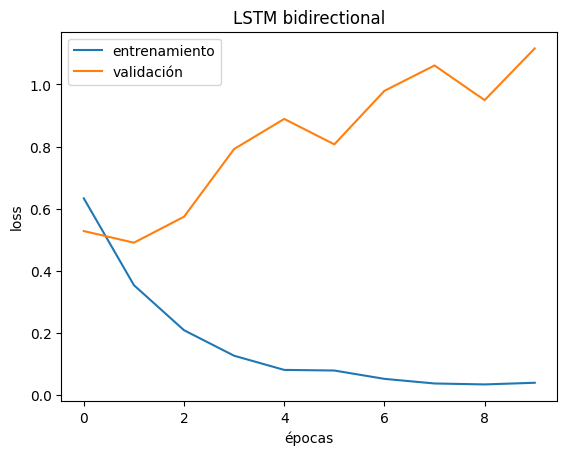

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7642 - loss: 1.1337
Accuracy:  0.7666117548942566


In [ ]:
from tensorflow.keras.layers import Bidirectional

max_words = 10000
embedding_size = 50

# Creamos una red con una capa de entrada de embeddings, una capa intermedia (oculta) con una biLSTM de tamaño 128, y una capa de salida con función de activación sigmoidal
model = Sequential()
# TO DO
model.add(Embedding(max_words, embedding_size, mask_zero=True))
model.add(Bidirectional(LSTM(128)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Entrenamos el modelo
history_bidirectional = model.fit(x_training, y_training, epochs=10, batch_size=128, validation_data=(x_validation, y_validation), verbose=2)

plt.plot(history_bidirectional.history['loss'])
plt.plot(history_bidirectional.history['val_loss'])
plt.title('LSTM bidirectional')
plt.ylabel('loss')
plt.xlabel('épocas')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])